# Figure 7F — B-SOiD three-chamber social behaviour clustermap

B-SOiD-labeled per-mouse recordings from the three-chamber Social Interaction Test, four perinatal-insult groups: **Sal-N**, **Sal-Hx**, **LPS-N**, **LPS-Hx**.

- **Figure 7F** — pooled-clustermap heatmap of B-SOiD cluster fractions per group, with average-linkage Euclidean dendrograms on rows and columns.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_context("notebook")

EXPERIMENTAL_GROUPS    = ["NS", "Hx", "LPS", "DH"]
CHAMBER_KEYS           = ["stranger_mouse_chamber", "middle_chamber", "novel_object_chamber"]
CHAMBER_TITLES         = {"stranger_mouse_chamber": "Stranger Mouse Chamber",
                          "middle_chamber":          "Middle Chamber",
                          "novel_object_chamber":    "Novel Object Chamber"}
GROUP_FIGURE_LABEL     = {"NS": "Sal-N", "Hx": "Sal-Hx", "LPS": "LPS-N", "DH": "LPS-Hx"}
GROUP_COLORS           = {"DH":  "#D32F2F", "Hx":  "#1976D2",
                          "LPS": "#FBC02D", "NS":  "#388E3C"}
GROUP_ORDER_LEGEND     = ["DH", "Hx", "LPS", "NS"]


def runs_for(rl_df, cluster, chamber, group):
    sub = rl_df[(rl_df["cluster"] == cluster) &
                (rl_df["chamber"] == chamber) &
                (rl_df["group"]   == group)]
    if sub.empty:
        return np.array([], dtype=int)
    return np.repeat(sub["run_length"].values, sub["count"].values)


def plot_cdfs(ax, rl_df, cluster, chamber, *,
              linewidth=2, fontsize_title=13, fontsize_y=12,
              fontsize_x=11, fontsize_tick=10, fontsize_legend=9,
              show_title=True, show_y=True, show_legend=True):
    max_x = 1
    for g in GROUP_ORDER_LEGEND:
        runs = runs_for(rl_df, cluster, chamber, g)
        if runs.size == 0:
            continue
        sorted_runs = np.sort(runs)
        cdf = np.cumsum(sorted_runs) / sorted_runs.sum()
        ax.step(sorted_runs, cdf, where="post", color=GROUP_COLORS[g],
                linewidth=linewidth, label=GROUP_FIGURE_LABEL[g])
        max_x = max(max_x, int(sorted_runs[-1]))
    ax.set_xscale("log")
    ax.set_xlim(left=1, right=max_x if max_x > 1 else None)
    ax.set_ylim(0, 1.0)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_linewidth(0.8)
    ax.tick_params(axis="both", which="both", labelsize=fontsize_tick)
    if show_title:
        ax.set_title(CHAMBER_TITLES[chamber], fontsize=fontsize_title, pad=10)
    if show_y:
        ax.set_ylabel(f"Group {cluster} CDF", fontsize=fontsize_y)
    ax.set_xlabel("Successive Frames (Log)", fontsize=fontsize_x, labelpad=2)
    if show_legend:
        ax.legend(loc="lower right", fontsize=fontsize_legend, frameon=False)


def sig_lookup_from(wasser_df):
    return (wasser_df.assign(sig=lambda d: d["Adjusted p-value (BH)"] < 0.05)
                     .groupby(["Label", "Chamber"])["sig"].any().to_dict())

def relabel(s):
    s = s.replace("DH",  "LPS-Hx")
    s = s.replace("Hx",  "Sal-Hx")
    s = s.replace("LPS", "LPS-N")
    s = s.replace("NS",  "Sal-N")
    return s

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


## Figure 7F — pooled clustermap

Fraction of B-SOiD-sampled frames spent in each behavioural cluster,
per group. Columns are fixed in manuscript order
(**Sal-N → Sal-Hx → LPS-N → LPS-Hx**); rows are ordered by hierarchical
clustering on the y-axis dendrogram, which reveals which behaviours
move together across groups.


In [2]:
fraction = pd.read_csv("data/bsoid_fraction_matrix.csv", index_col=0)
fraction.columns = ["NS", "Hx", "LPS", "DH"]
CUSTOM_GROUP_LABELS = ["Sal-N", "Sal-Hx", "LPS-N", "LPS-Hx"]
BSOID_LABELS = list(range(14))
fraction.round(4)


,NS,Hx,LPS,DH
0,0.0481,0.0312,0.0456,0.0628
1,0.1629,0.1192,0.1812,0.1257
2,0.0697,0.0342,0.0640,0.0627
3,0.0723,0.0911,0.0572,0.0686
4,0.0207,0.0138,0.0282,0.0236
5,0.0294,0.0469,0.0318,0.0187
6,0.0309,0.0857,0.0458,0.0566
7,0.1399,0.0844,0.1161,0.2406
8,0.1303,0.0968,0.0921,0.1724
9,0.0400,0.0165,0.0952,0.0260


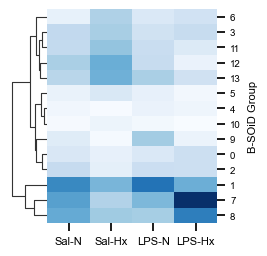

In [3]:
# ---- Figure 7F — pooled clustermap (canonical) ----
# Y-axis dendrogram retained: it reveals which behavioural clusters move
# together across groups. X-axis dendrogram removed; columns are fixed to
# the manuscript group order (Sal-N -> Sal-Hx -> LPS-N -> LPS-Hx).
# Colour map (colorbar) removed per panel design. Output sized to the Fig 7F
# panel slot: figsize (2.73, 3.20) -> ~2.68in W x 2.57in H at 600 dpi with
# bbox_inches="tight" (aspect ~1.04). Dropping the colorbar widens the
# heatmap, so the group labels sit at 8pt with clean gaps.
fraction_ordered = fraction[['NS', 'Hx', 'LPS', 'DH']]   # manuscript order
g = sns.clustermap(
    fraction_ordered, cmap='Blues',
    row_cluster=True, col_cluster=False,
    xticklabels=CUSTOM_GROUP_LABELS, yticklabels=BSOID_LABELS,
    figsize=(2.73, 3.20),    # -> ~2.68in x 2.57in @600dpi after tight bbox
    dendrogram_ratio=(0.18, 0.02),
    cbar_pos=None,           # no colorbar / colour map
    tree_kws={'linewidths': 0.8},
)
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel('')
g.fig.patch.set_facecolor('white')
g.ax_heatmap.set_facecolor('white')
g.ax_heatmap.set_ylabel('B-SOiD Group', fontsize=8)
g.ax_heatmap.yaxis.labelpad = 5
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8, rotation=0)
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7, rotation=0)
g.fig.savefig('Fig7F.png', dpi=600, bbox_inches='tight', facecolor='white')
g.fig.savefig('Fig7F.pdf',          bbox_inches='tight', facecolor='white')
plt.show()


### Row dendrogram linkage matrix

In [4]:
pd.read_csv("data/row_linkage.csv").round(4)

,c1,c2,dist,size
0,4.0,10.0,0.0192,2.0
1,0.0,2.0,0.0286,2.0
2,3.0,11.0,0.0298,2.0
3,5.0,14.0,0.0322,3.0
4,12.0,13.0,0.0385,2.0
5,16.0,18.0,0.0435,4.0
6,9.0,15.0,0.0617,3.0
7,6.0,19.0,0.0630,5.0
8,17.0,20.0,0.0696,6.0
9,7.0,8.0,0.0739,2.0


### Column dendrogram linkage matrix

In [5]:
pd.read_csv("data/col_linkage.csv").round(4)

,c1,c2,dist,size
0,0.0,2.0,0.0811,2.0
1,1.0,4.0,0.1375,3.0
2,3.0,5.0,0.1840,4.0
